# 🛰️ CarbonIQ — CNN Facility Classifier
### Dataset: NWPU-RESISC45 · Model: MobileNetV2 Transfer Learning

| Config | Value |
|--------|-------|
| Dataset | NWPU-RESISC45 (Kaggle) |
| Classes used | **12** (carbon-relevant only) |
| Images per class | **150** (from 700 available) |
| Total images | ~1,800 |
| Base model | MobileNetV2 (ImageNet, frozen) |
| Phase 1 epochs | 10 (head only) |
| Phase 2 epochs | 10 (fine-tune top 20 layers) |
| Expected time | **~5–8 min CPU · ~2 min GPU** |

**Pipeline:** `Image → CNN → facility_type → sector + fuel → ANN → CO₂ → RAG`

## 📦 Section 1 — Imports & Setup

In [ ]:
import os, json, random, shutil, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print(f'TensorFlow : {tf.__version__}')
print(f'GPU found  : {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow : 2.19.0
GPU found  : True


## ⚙️ Section 2 — Configuration

In [ ]:
# ── Paths ──────────────────────────────────────────────────────────────────────
BASE_DIR      = Path('.')
DATA_DIR      = BASE_DIR / 'data' / 'resisc45_subset'
TRAIN_DIR     = DATA_DIR / 'train'
VAL_DIR       = DATA_DIR / 'val'
TEST_DIR      = DATA_DIR / 'test'
ARTIFACTS_DIR = BASE_DIR / 'models_artifacts'
PLOTS_DIR     = BASE_DIR / 'plots'
for d in [ARTIFACTS_DIR, PLOTS_DIR]: d.mkdir(parents=True, exist_ok=True)

# Clean up previous data directory to force rebuild
if DATA_DIR.exists():
    print(f"Cleaning up existing data directory: {DATA_DIR}")
    shutil.rmtree(DATA_DIR)
DATA_DIR.mkdir(parents=True, exist_ok=True) # Ensure DATA_DIR itself exists for subfolders

# ── Subset — KEEP SMALL FOR FAST TRAINING ─────────────────────────────────────
IMAGES_PER_CLASS = 150    # only 150 of 700 per class
TRAIN_RATIO      = 0.70
VAL_RATIO        = 0.15

# ── 12 carbon-relevant classes ────────────────────────────────────────────────
SELECTED_CLASSES = [
    'thermal_power_station',  # Electric Power · Coal
    'industrial_area',        # Industrial · Natural Gas
    'storage_tank',           # Petroleum · Petroleum
    # 'wind_mill',            # Electric Power · Wind (removed due to missing data)
    'airport',                # Transportation · Petroleum
    'railway_station',        # Transportation · Petroleum
    'harbor',                 # Transportation · Petroleum
    'commercial_area',        # Commercial · Natural Gas
    'dense_residential',      # Residential · Natural Gas
    'rectangular_farmland',   # Agriculture · Natural Gas
    'forest',                 # Residential · Biomass
    'freeway',                # Transportation · Petroleum',
]
NUM_CLASSES = len(SELECTED_CLASSES)

CLASS_TO_SECTOR = {
    'thermal_power_station': 'Electric Power carbon dioxide emissions',
    'industrial_area':       'Industrial carbon dioxide emissions',
    'storage_tank':          'Petroleum Systems carbon dioxide emissions',
    'wind_mill':             'Electric Power carbon dioxide emissions',
    'airport':               'Transportation carbon dioxide emissions',
    'railway_station':       'Transportation carbon dioxide emissions',
    'harbor':                'Transportation carbon dioxide emissions',
    'commercial_area':       'Commercial carbon dioxide emissions',
    'dense_residential':     'Residential carbon dioxide emissions',
    'rectangular_farmland':  'Agriculture carbon dioxide emissions',
    'forest':                'Residential carbon dioxide emissions',
    'freeway':               'Transportation carbon dioxide emissions',
}
CLASS_TO_FUEL = {
    'thermal_power_station': 'Coal',       'industrial_area':      'Natural Gas',
    'storage_tank':          'Petroleum',  'wind_mill':            'Wind',
    'airport':               'Petroleum',  'railway_station':      'Petroleum',
    'harbor':                'Petroleum',  'commercial_area':      'Natural Gas',
    'dense_residential':     'Natural Gas','rectangular_farmland': 'Natural Gas',
    'forest':                'Biomass',    'freeway':              'Petroleum',
}

# ── Model hyperparameters ──────────────────────────────────────────────────────
IMG_SIZE        = (224, 224)
BATCH_SIZE      = 32
EPOCHS_PHASE1   = 10
EPOCHS_PHASE2   = 10
LR_PHASE1       = 1e-3
LR_PHASE2       = 1e-5
UNFREEZE_LAYERS = 20
DROPOUT         = 0.4
DENSE_UNITS     = 256

print(f'Classes          : {NUM_CLASSES}')
print(f'Images per class : {IMAGES_PER_CLASS}')
print(f'Total images     : ~{NUM_CLASSES * IMAGES_PER_CLASS}')
print(f'Est. train       : ~{int(NUM_CLASSES * IMAGES_PER_CLASS * TRAIN_RATIO)}')

Cleaning up existing data directory: data/resisc45_subset
Classes          : 11
Images per class : 150
Total images     : ~1650
Est. train       : ~1155


## 📥 Section 3 — Download NWPU-RESISC45

In [ ]:
import kagglehub

# Requires ~/.kaggle/kaggle.json  (get from kaggle.com → Settings → API)
print('Downloading NWPU-RESISC45 from Kaggle...')
raw_path = kagglehub.dataset_download('aqibrehmanpirzada/nwpuresisc45')
RAW_DIR  = Path(raw_path)
print(f'Downloaded to: {RAW_DIR}')

# Auto-detect class root (dataset may be nested)
CLASS_ROOT = None

# Search for the directory that contains all SELECTED_CLASSES
# AND has a sufficient number of images in at least one of them (as a heuristic)
for current_dir, _, _ in os.walk(RAW_DIR):
    current_path = Path(current_dir)
    # Check if all selected classes exist as subdirectories
    if all((current_path / cls).is_dir() for cls in SELECTED_CLASSES):
        # Additional check: Does at least one of these classes contain enough images?
        # This helps differentiate between a full dataset and a partial test set structure.
        # We check the first selected class as a heuristic, assuming consistent image counts.
        first_class_path = current_path / SELECTED_CLASSES[0]
        if first_class_path.is_dir():
            num_images_in_first_class = len(list(first_class_path.glob('*.jpg')))
            if num_images_in_first_class >= IMAGES_PER_CLASS:
                CLASS_ROOT = current_path
                break

assert CLASS_ROOT is not None, f'Class folders (containing enough images for selected classes) not found under {RAW_DIR}. Searched recursively. Please check the dataset structure.'

all_cls = sorted([d.name for d in CLASS_ROOT.iterdir() if d.is_dir()])
print(f'Class root  : {CLASS_ROOT}')
print(f'Total cls   : {len(all_cls)}')
missing = [c for c in SELECTED_CLASSES if c not in all_cls]
if missing:
    print(f'WARNING missing: {missing}')
    print(f'Available: {all_cls}')
    # Optionally, raise an error if critical classes are missing
    # assert not missing, f"Some SELECTED_CLASSES are missing from the detected CLASS_ROOT: {missing}"
else:
    print(f'All {NUM_CLASSES} selected classes found!')

Using Colab cache for faster access to the 'nwpuresisc45' dataset.
Downloaded to: /kaggle/input/nwpuresisc45
Class root  : /kaggle/input/nwpuresisc45/Dataset/train/train
Total cls   : 45
All 11 selected classes found!


## 🗂️ Section 4 — Build Focused Subset (150 imgs/class)

In [ ]:
def build_subset(class_root, dest_root, classes, n=150, seed=42):
    if dest_root.exists() and any(dest_root.iterdir()):
        print('Subset already built — skipping.')
        return
    random.seed(seed)
    totals = {s: 0 for s in ['train', 'val', 'test']}
    print(f'Building {n} imgs × {len(classes)} classes...')
    for cls in classes:
        imgs = random.sample(
            sorted(list((class_root / cls).glob('*.jpg'))), min(n, 700)
        )
        n_tr = int(len(imgs) * TRAIN_RATIO)
        n_vl = int(len(imgs) * VAL_RATIO)
        splits = {'train': imgs[:n_tr],
                  'val':   imgs[n_tr:n_tr+n_vl],
                  'test':  imgs[n_tr+n_vl:]}
        for sp, sp_imgs in splits.items():
            dst = dest_root / sp / cls
            dst.mkdir(parents=True, exist_ok=True)
            for img in sp_imgs: shutil.copy2(img, dst / img.name)
            totals[sp] += len(sp_imgs)
        print(f'  {cls:<28} tr={len(splits["train"])} vl={len(splits["val"])} te={len(splits["test"])}')
    print(f'Done → train:{totals["train"]} val:{totals["val"]} test:{totals["test"]}')

build_subset(CLASS_ROOT, DATA_DIR, SELECTED_CLASSES, n=IMAGES_PER_CLASS)

Building 150 imgs × 11 classes...
  thermal_power_station        tr=105 vl=22 te=23
  industrial_area              tr=105 vl=22 te=23
  storage_tank                 tr=105 vl=22 te=23
  airport                      tr=105 vl=22 te=23
  railway_station              tr=105 vl=22 te=23
  harbor                       tr=105 vl=22 te=23
  commercial_area              tr=105 vl=22 te=23
  dense_residential            tr=105 vl=22 te=23
  rectangular_farmland         tr=105 vl=22 te=23
  forest                       tr=105 vl=22 te=23
  freeway                      tr=105 vl=22 te=23
Done → train:1155 val:242 test:253


## 🔍 Section 5 — EDA: Sample Grid + Class Distribution

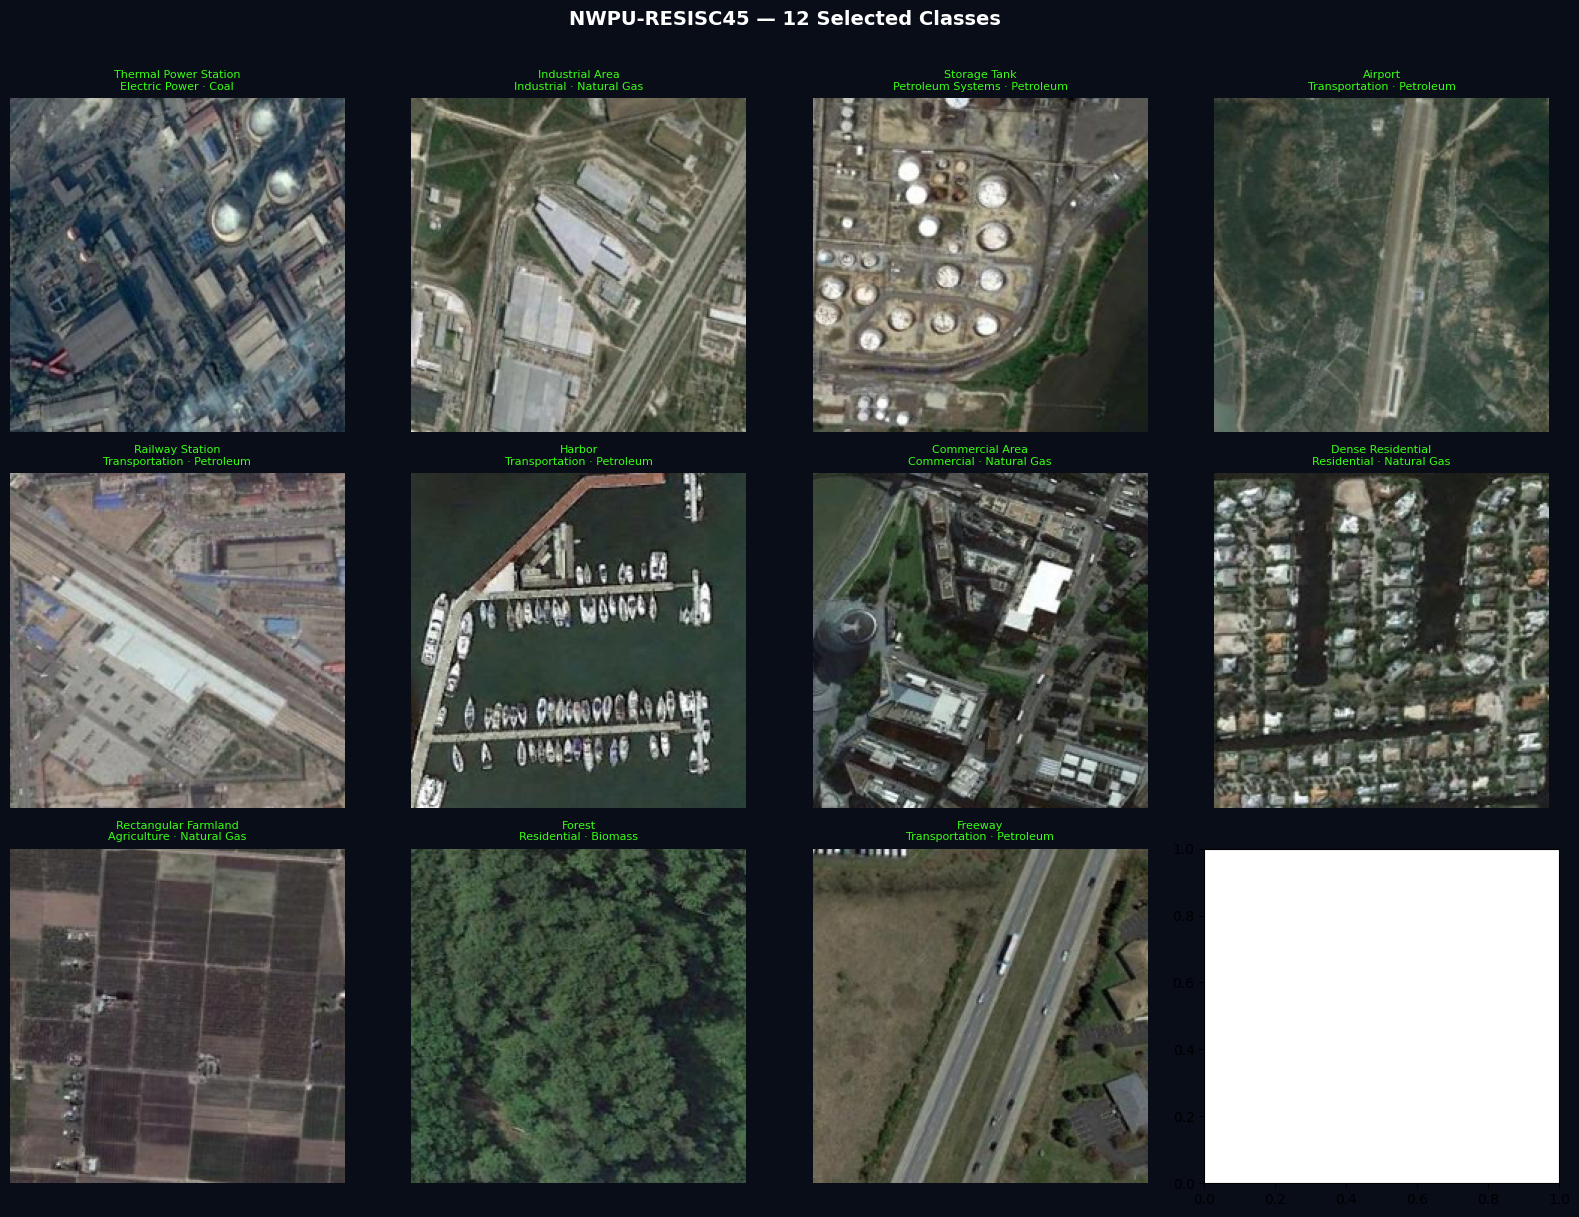

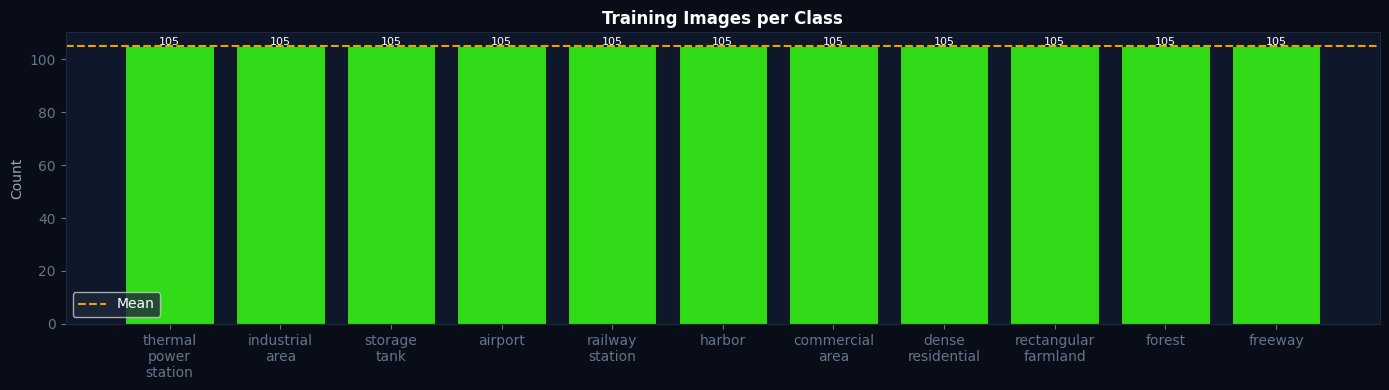

Total train images: 1155


In [ ]:
# Sample image grid
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.patch.set_facecolor('#080d18')
fig.suptitle('NWPU-RESISC45 — 12 Selected Classes', color='white',
             fontsize=14, fontweight='bold', y=1.01)
for ax, cls in zip(axes.flat, SELECTED_CLASSES):
    imgs = list((TRAIN_DIR / cls).glob('*.jpg'))
    img  = Image.open(random.choice(imgs)).convert('RGB').resize((224, 224))
    ax.imshow(img)
    fuel   = CLASS_TO_FUEL[cls]
    sector = CLASS_TO_SECTOR[cls].replace(' carbon dioxide emissions', '')
    ax.set_title(f"{cls.replace('_',' ').title()}\n{sector} · {fuel}",
                 color='#39ff14', fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.savefig(PLOTS_DIR/'01_sample_grid.png', dpi=150, bbox_inches='tight', facecolor='#080d18')
plt.show()

# Class distribution
counts = {cls: len(list((TRAIN_DIR/cls).glob('*.jpg'))) for cls in SELECTED_CLASSES}
fig, ax = plt.subplots(figsize=(14, 4))
fig.patch.set_facecolor('#080d18')
ax.set_facecolor('#0f172a')
bars = ax.bar([c.replace('_','\n') for c in SELECTED_CLASSES],
              counts.values(), color='#39ff14', edgecolor='#080d18', linewidth=0.8, alpha=0.85)
ax.axhline(np.mean(list(counts.values())), color='#f59e0b', ls='--', label='Mean')
for bar, v in zip(bars, counts.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            str(v), ha='center', color='white', fontsize=8)
ax.set_title('Training Images per Class', color='white', fontweight='bold')
ax.set_ylabel('Count', color='#94a3b8')
ax.tick_params(colors='#64748b')
for sp in ax.spines.values(): sp.set_edgecolor('#1e293b')
ax.legend(facecolor='#1e293b', labelcolor='white')
plt.tight_layout()
plt.savefig(PLOTS_DIR/'02_class_dist.png', dpi=150, bbox_inches='tight', facecolor='#080d18')
plt.show()
print(f'Total train images: {sum(counts.values())}')

## 🔄 Section 6 — Data Generators with Augmentation

Found 1155 images belonging to 11 classes.
Found 242 images belonging to 11 classes.
Found 253 images belonging to 11 classes.
Classes : ['airport', 'commercial_area', 'dense_residential', 'forest', 'freeway', 'harbor', 'industrial_area', 'railway_station', 'rectangular_farmland', 'storage_tank', 'thermal_power_station']
Train batches: 37 | Val: 8 | Test: 8


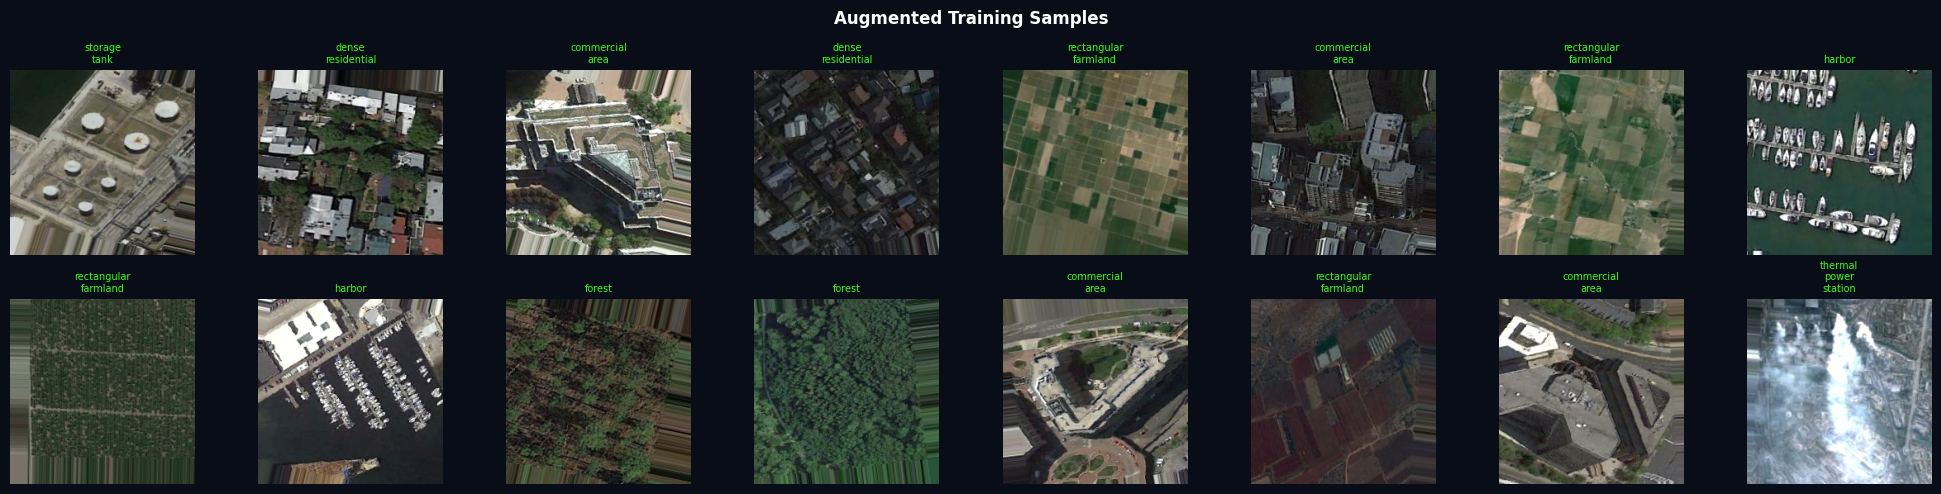

In [ ]:
train_gen = ImageDataGenerator(
    rescale=1./255, rotation_range=20,
    width_shift_range=0.1, height_shift_range=0.1,
    zoom_range=0.15, horizontal_flip=True, vertical_flip=True,
    brightness_range=[0.8, 1.2], fill_mode='nearest',
).flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, seed=SEED,
)

eval_dg = ImageDataGenerator(rescale=1./255)
val_gen  = eval_dg.flow_from_directory(VAL_DIR,  target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
test_gen = eval_dg.flow_from_directory(TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

CLASS_NAMES  = list(train_gen.class_indices.keys())
IDX_TO_CLASS = {v: k for k, v in train_gen.class_indices.items()}
print(f'Classes : {CLASS_NAMES}')
print(f'Train batches: {len(train_gen)} | Val: {len(val_gen)} | Test: {len(test_gen)}')

# Augmented sample preview
imgs_b, lbls_b = next(iter(train_gen))
fig, axes = plt.subplots(2, 8, figsize=(20, 5))
fig.patch.set_facecolor('#080d18')
fig.suptitle('Augmented Training Samples', color='white', fontsize=12, fontweight='bold')
for ax, img, lbl in zip(axes.flat, imgs_b[:16], lbls_b[:16]):
    ax.imshow(img)
    ax.set_title(IDX_TO_CLASS[np.argmax(lbl)].replace('_','\n'), color='#39ff14', fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.savefig(PLOTS_DIR/'03_augmented.png', dpi=150, bbox_inches='tight', facecolor='#080d18')
plt.show()

## 🧠 Section 7 — Build MobileNetV2 Model

In [ ]:
base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
base.trainable = False   # Freeze all for Phase 1

inputs  = keras.Input(shape=(*IMG_SIZE, 3), name='image_input')
x       = base(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(DENSE_UNITS, activation='relu',
                        kernel_regularizer=regularizers.l2(1e-4))(x)
x       = layers.Dropout(DROPOUT)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax', name='predictions')(x)
model   = Model(inputs, outputs, name='CarbonIQ_CNN')

trainable = sum(np.prod(v.shape) for v in model.trainable_variables)
print(f'Total params     : {model.count_params():,}')
print(f'Trainable Ph1    : {trainable:,}  (head only — fast!)')
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total params     : 2,593,867
Trainable Ph1    : 333,323  (head only — fast!)


Model: "CarbonIQ_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 11)             │         2,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,593,867 (9.89 MB)

 Trainable params: 333,323 (1.27 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

## 🚀 Section 8 — Phase 1: Train Head Only

In [ ]:
model.compile(
    optimizer=Adam(LR_PHASE1), loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')],
)
cb_p1 = [
    callbacks.ModelCheckpoint(str(ARTIFACTS_DIR/'cnn_p1_best.keras'),
                               monitor='val_accuracy', save_best_only=True, verbose=0),
    callbacks.EarlyStopping(monitor='val_accuracy', patience=4,
                             restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2,
                                 min_lr=1e-7, verbose=0),
]
print('=== PHASE 1 — Head only (base frozen) ===\n')
h1 = model.fit(train_gen, epochs=EPOCHS_PHASE1, validation_data=val_gen,
               callbacks=cb_p1, verbose=1)
print(f'\nBest val acc: {max(h1.history["val_accuracy"]):.4f}')

=== PHASE 1 — Head only (base frozen) ===

Epoch 1/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.6061 - loss: 1.3348 - top3_acc: 0.8121 - val_accuracy: 0.7810 - val_loss: 0.7495 - val_top3_acc: 0.9256 - learning_rate: 0.0010
Epoch 2/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 18s 486ms/step - accuracy: 0.8035 - loss: 0.6439 - top3_acc: 0.9584 - val_accuracy: 0.8306 - val_loss: 0.5520 - val_top3_acc: 0.9587 - learning_rate: 0.0010
Epoch 3/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 16s 444ms/step - accuracy: 0.8468 - loss: 0.5184 - top3_acc: 0.9662 - val_accuracy: 0.8760 - val_loss: 0.4138 - val_top3_acc: 0.9711 - learning_rate: 0.0010
Epoch 4/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 16s 441ms/step - accuracy: 0.8823 - loss: 0.3954 - top3_acc: 0.9818 - val_accuracy: 0.8843 - val_loss: 0.3944 - val_top3_acc: 0.9711 - learning_rate: 0.0010
Epoch 5/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 18s 482ms/step - accuracy: 0.8762 - loss: 0.4346 - top3_acc: 0.9749 - val_accuracy: 0.8802 - val_loss: 0.3864 - val_top3_acc: 0.9752 - learnin

## 🔓 Section 9 — Phase 2: Fine-Tune Top 20 Layers

In [ ]:
base.trainable = True
for layer in base.layers[:-UNFREEZE_LAYERS]: layer.trainable = False
print(f'Trainable params Ph2: {sum(np.prod(v.shape) for v in model.trainable_variables):,}')

model.compile(
    optimizer=Adam(LR_PHASE2), loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')],
)
cb_p2 = [
    callbacks.ModelCheckpoint(str(ARTIFACTS_DIR/'cnn_p2_best.keras'),
                               monitor='val_accuracy', save_best_only=True, verbose=0),
    callbacks.EarlyStopping(monitor='val_accuracy', patience=5,
                             restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2,
                                 min_lr=1e-8, verbose=0),
]
print('=== PHASE 2 — Fine-tuning top 20 base layers ===\n')
h2 = model.fit(train_gen, epochs=EPOCHS_PHASE2, validation_data=val_gen,
               callbacks=cb_p2, verbose=1)
print(f'\nBest val acc: {max(h2.history["val_accuracy"]):.4f}')

Trainable params Ph2: 1,539,403
=== PHASE 2 — Fine-tuning top 20 base layers ===

Epoch 1/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 48s 900ms/step - accuracy: 0.8095 - loss: 0.6713 - top3_acc: 0.9550 - val_accuracy: 0.9091 - val_loss: 0.3362 - val_top3_acc: 0.9876 - learning_rate: 1.0000e-05
Epoch 2/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 16s 444ms/step - accuracy: 0.8182 - loss: 0.5746 - top3_acc: 0.9662 - val_accuracy: 0.8926 - val_loss: 0.3579 - val_top3_acc: 0.9876 - learning_rate: 1.0000e-05
Epoch 3/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 17s 466ms/step - accuracy: 0.8173 - loss: 0.5784 - top3_acc: 0.9654 - val_accuracy: 0.8802 - val_loss: 0.3884 - val_top3_acc: 0.9835 - learning_rate: 1.0000e-05
Epoch 4/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 16s 435ms/step - accuracy: 0.8242 - loss: 0.5621 - top3_acc: 0.9662 - val_accuracy: 0.8843 - val_loss: 0.4112 - val_top3_acc: 0.9835 - learning_rate: 5.0000e-06
Epoch 5/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 16s 442ms/step - accuracy: 0.8545 - loss: 0.5386 - top3_acc: 0.9706 - val_accuracy: 

## 📊 Section 10 — Training History

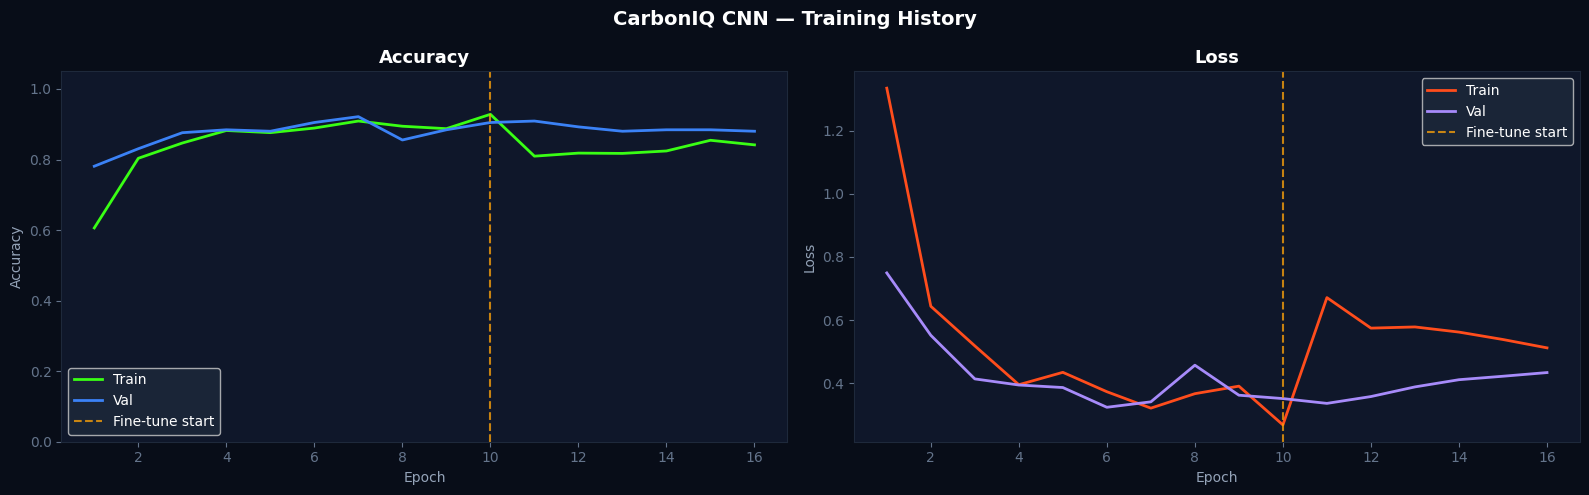

Best val acc : 0.9215 @ epoch 7


In [ ]:
acc      = h1.history['accuracy']     + h2.history['accuracy']
val_acc  = h1.history['val_accuracy'] + h2.history['val_accuracy']
loss     = h1.history['loss']         + h2.history['loss']
val_loss = h1.history['val_loss']     + h2.history['val_loss']
p1_len   = len(h1.history['accuracy'])
epochs   = range(1, len(acc)+1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#080d18')
for ax in (ax1, ax2):
    ax.set_facecolor('#0f172a')
    for sp in ax.spines.values(): sp.set_edgecolor('#1e293b')
    ax.tick_params(colors='#64748b')

ax1.plot(epochs, acc,    '#39ff14', lw=2, label='Train')
ax1.plot(epochs, val_acc,'#3b82f6', lw=2, label='Val')
ax1.axvline(p1_len, color='#f59e0b', ls='--', alpha=0.8, label='Fine-tune start')
ax1.set_title('Accuracy', color='white', fontweight='bold', fontsize=13)
ax1.set_xlabel('Epoch', color='#94a3b8'); ax1.set_ylabel('Accuracy', color='#94a3b8')
ax1.set_ylim([0, 1.05]); ax1.legend(facecolor='#1e293b', labelcolor='white')

ax2.plot(epochs, loss,    '#ff4d1c', lw=2, label='Train')
ax2.plot(epochs, val_loss,'#a78bfa', lw=2, label='Val')
ax2.axvline(p1_len, color='#f59e0b', ls='--', alpha=0.8, label='Fine-tune start')
ax2.set_title('Loss', color='white', fontweight='bold', fontsize=13)
ax2.set_xlabel('Epoch', color='#94a3b8'); ax2.set_ylabel('Loss', color='#94a3b8')
ax2.legend(facecolor='#1e293b', labelcolor='white')

fig.suptitle('CarbonIQ CNN — Training History', color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR/'04_training_history.png', dpi=150, bbox_inches='tight', facecolor='#080d18')
plt.show()
print(f'Best val acc : {max(val_acc):.4f} @ epoch {val_acc.index(max(val_acc))+1}')

## 🧪 Section 11 — Evaluation on Test Set

Loaded: cnn_p2_best.keras
8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.8735 - loss: 0.4725 - top3_acc: 0.9684

Test Accuracy : 87.35%
Top-3 Acc     : 96.84%
Test Loss     : 0.4725
8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 649ms/step


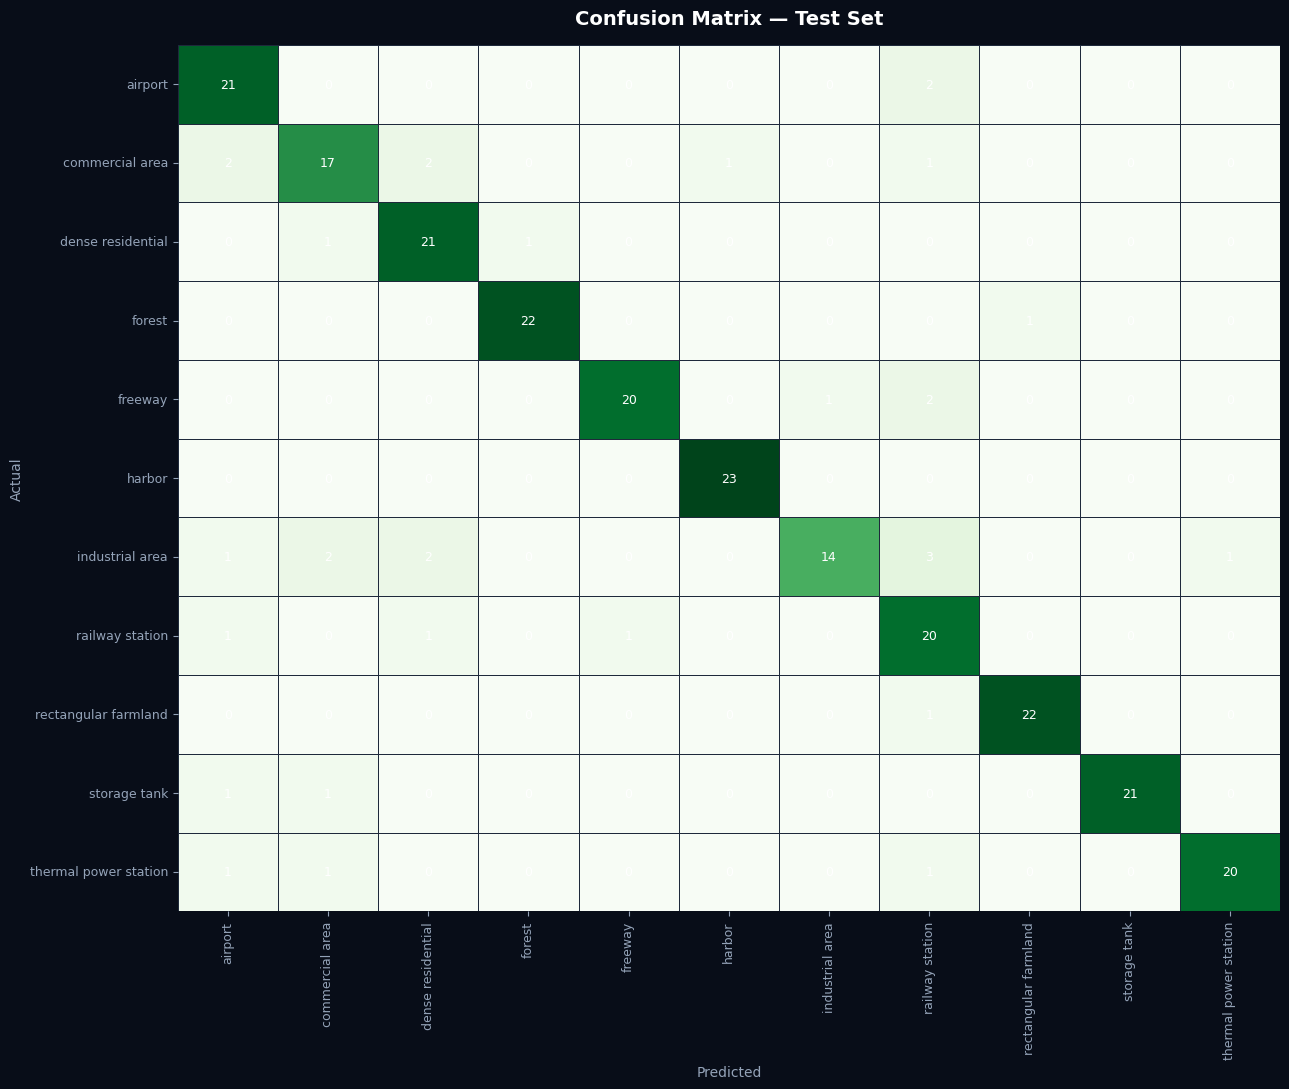


Classification Report:
                       precision    recall  f1-score   support

              airport      0.778     0.913     0.840        23
      commercial_area      0.773     0.739     0.756        23
    dense_residential      0.808     0.913     0.857        23
               forest      0.957     0.957     0.957        23
              freeway      0.952     0.870     0.909        23
               harbor      0.958     1.000     0.979        23
      industrial_area      0.933     0.609     0.737        23
      railway_station      0.667     0.870     0.755        23
 rectangular_farmland      0.957     0.957     0.957        23
         storage_tank      1.000     0.913     0.955        23
thermal_power_station      0.952     0.870     0.909        23

             accuracy                          0.874       253
            macro avg      0.885     0.874     0.874       253
         weighted avg      0.885     0.874     0.874       253



In [ ]:
ckpt = ARTIFACTS_DIR/'cnn_p2_best.keras'
if not ckpt.exists(): ckpt = ARTIFACTS_DIR/'cnn_p1_best.keras'
best_model = keras.models.load_model(str(ckpt))
print(f'Loaded: {ckpt.name}')

test_gen.reset()
results = best_model.evaluate(test_gen, verbose=1)
print(f'\nTest Accuracy : {results[1]*100:.2f}%')
print(f'Top-3 Acc     : {results[2]*100:.2f}%')
print(f'Test Loss     : {results[0]:.4f}')

test_gen.reset()
y_prob = best_model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_gen.classes

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(13, 11))
fig.patch.set_facecolor('#080d18'); ax.set_facecolor('#0f172a')
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax, cbar=False,
            xticklabels=[c.replace('_',' ') for c in CLASS_NAMES],
            yticklabels=[c.replace('_',' ') for c in CLASS_NAMES],
            linewidths=0.5, linecolor='#1e293b',
            annot_kws={'size': 9, 'color': 'white'})
ax.set_title('Confusion Matrix — Test Set', color='white', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Predicted', color='#94a3b8'); ax.set_ylabel('Actual', color='#94a3b8')
ax.tick_params(colors='#94a3b8', labelsize=9)
plt.tight_layout()
plt.savefig(PLOTS_DIR/'05_confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor='#080d18')
plt.show()

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=3))

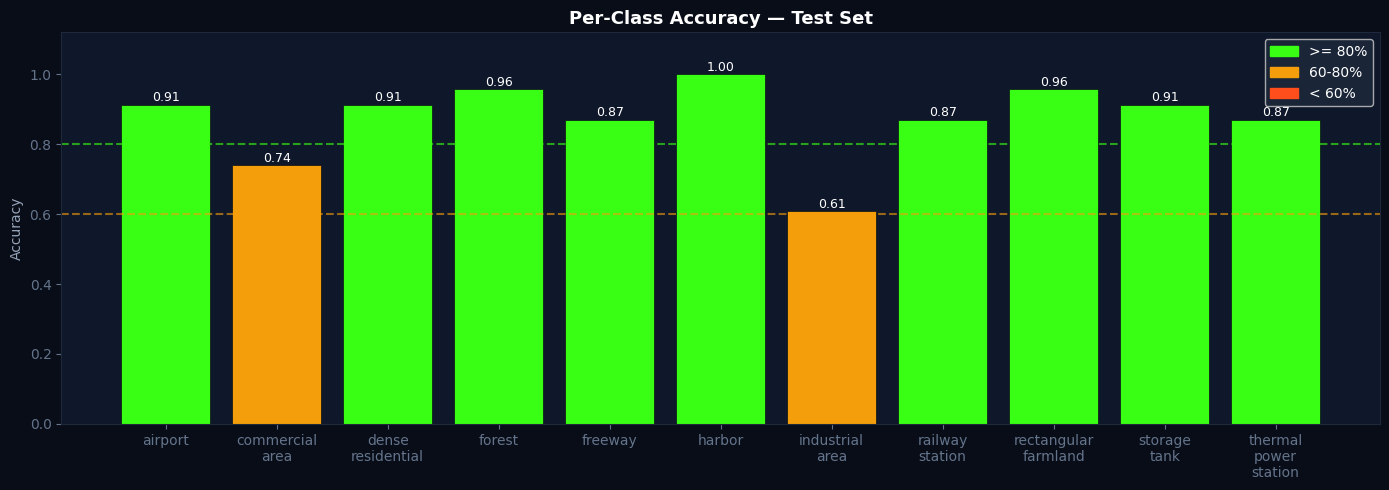

In [ ]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#080d18'); ax.set_facecolor('#0f172a')
colors = ['#39ff14' if a>=0.80 else '#f59e0b' if a>=0.60 else '#ff4d1c' for a in per_class_acc]
bars = ax.bar([c.replace('_','\n') for c in CLASS_NAMES],
              per_class_acc, color=colors, edgecolor='#080d18', linewidth=0.5)
for bar, a in zip(bars, per_class_acc):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{a:.2f}', ha='center', color='white', fontsize=9)
ax.axhline(0.80, color='#39ff14', ls='--', alpha=0.6)
ax.axhline(0.60, color='#f59e0b', ls='--', alpha=0.6)
ax.set_title('Per-Class Accuracy — Test Set', color='white', fontweight='bold', fontsize=13)
ax.set_ylabel('Accuracy', color='#94a3b8'); ax.set_ylim([0, 1.12])
ax.tick_params(colors='#64748b')
for sp in ax.spines.values(): sp.set_edgecolor('#1e293b')
ax.legend(handles=[
    mpatches.Patch(color='#39ff14', label='>= 80%'),
    mpatches.Patch(color='#f59e0b', label='60-80%'),
    mpatches.Patch(color='#ff4d1c', label='< 60%'),
], facecolor='#1e293b', labelcolor='white')
plt.tight_layout()
plt.savefig(PLOTS_DIR/'06_per_class_acc.png', dpi=150, bbox_inches='tight', facecolor='#080d18')
plt.show()

## 🔮 Section 12 — Inference Function + Prediction Grid

In [ ]:
def predict_facility(image_path: str, mdl=None, top_k: int = 3) -> dict:
    """Mirrors cnn_service.py in the FastAPI backend exactly."""
    if mdl is None: mdl = best_model
    img  = Image.open(image_path).convert('RGB').resize(IMG_SIZE)
    x    = np.expand_dims(np.array(img, dtype=np.float32)/255.0, axis=0)
    prob = mdl.predict(x, verbose=0)[0]
    top  = np.argsort(prob)[::-1][:top_k]
    preds = [{'class': IDX_TO_CLASS[i], 'confidence': round(float(prob[i]), 4)} for i in top]
    best  = preds[0]
    return {
        'facility_type':    best['class'],
        'confidence':       best['confidence'],
        'suggested_sector': CLASS_TO_SECTOR.get(best['class'], 'Industrial carbon dioxide emissions'),
        'suggested_fuel':   CLASS_TO_FUEL.get(best['class'], 'Natural Gas'),
        'top_predictions':  preds,
        'can_auto_fill':    best['confidence'] >= 0.55,
    }

# Quick test
all_test = list(TEST_DIR.rglob('*.jpg'))
s = random.choice(all_test)
r = predict_facility(str(s))
print(f'Image         : {s.name}')
print(f'True class    : {s.parent.name}')
print(f'Predicted     : {r["facility_type"]} ({r["confidence"]*100:.1f}%)')
print(f'Sector        : {r["suggested_sector"]}')
print(f'Fuel          : {r["suggested_fuel"]}')
print(f'Can auto-fill : {r["can_auto_fill"]}')

Image         : forest_483.jpg
True class    : forest
Predicted     : forest (100.0%)
Sector        : Residential carbon dioxide emissions
Fuel          : Biomass
Can auto-fill : True


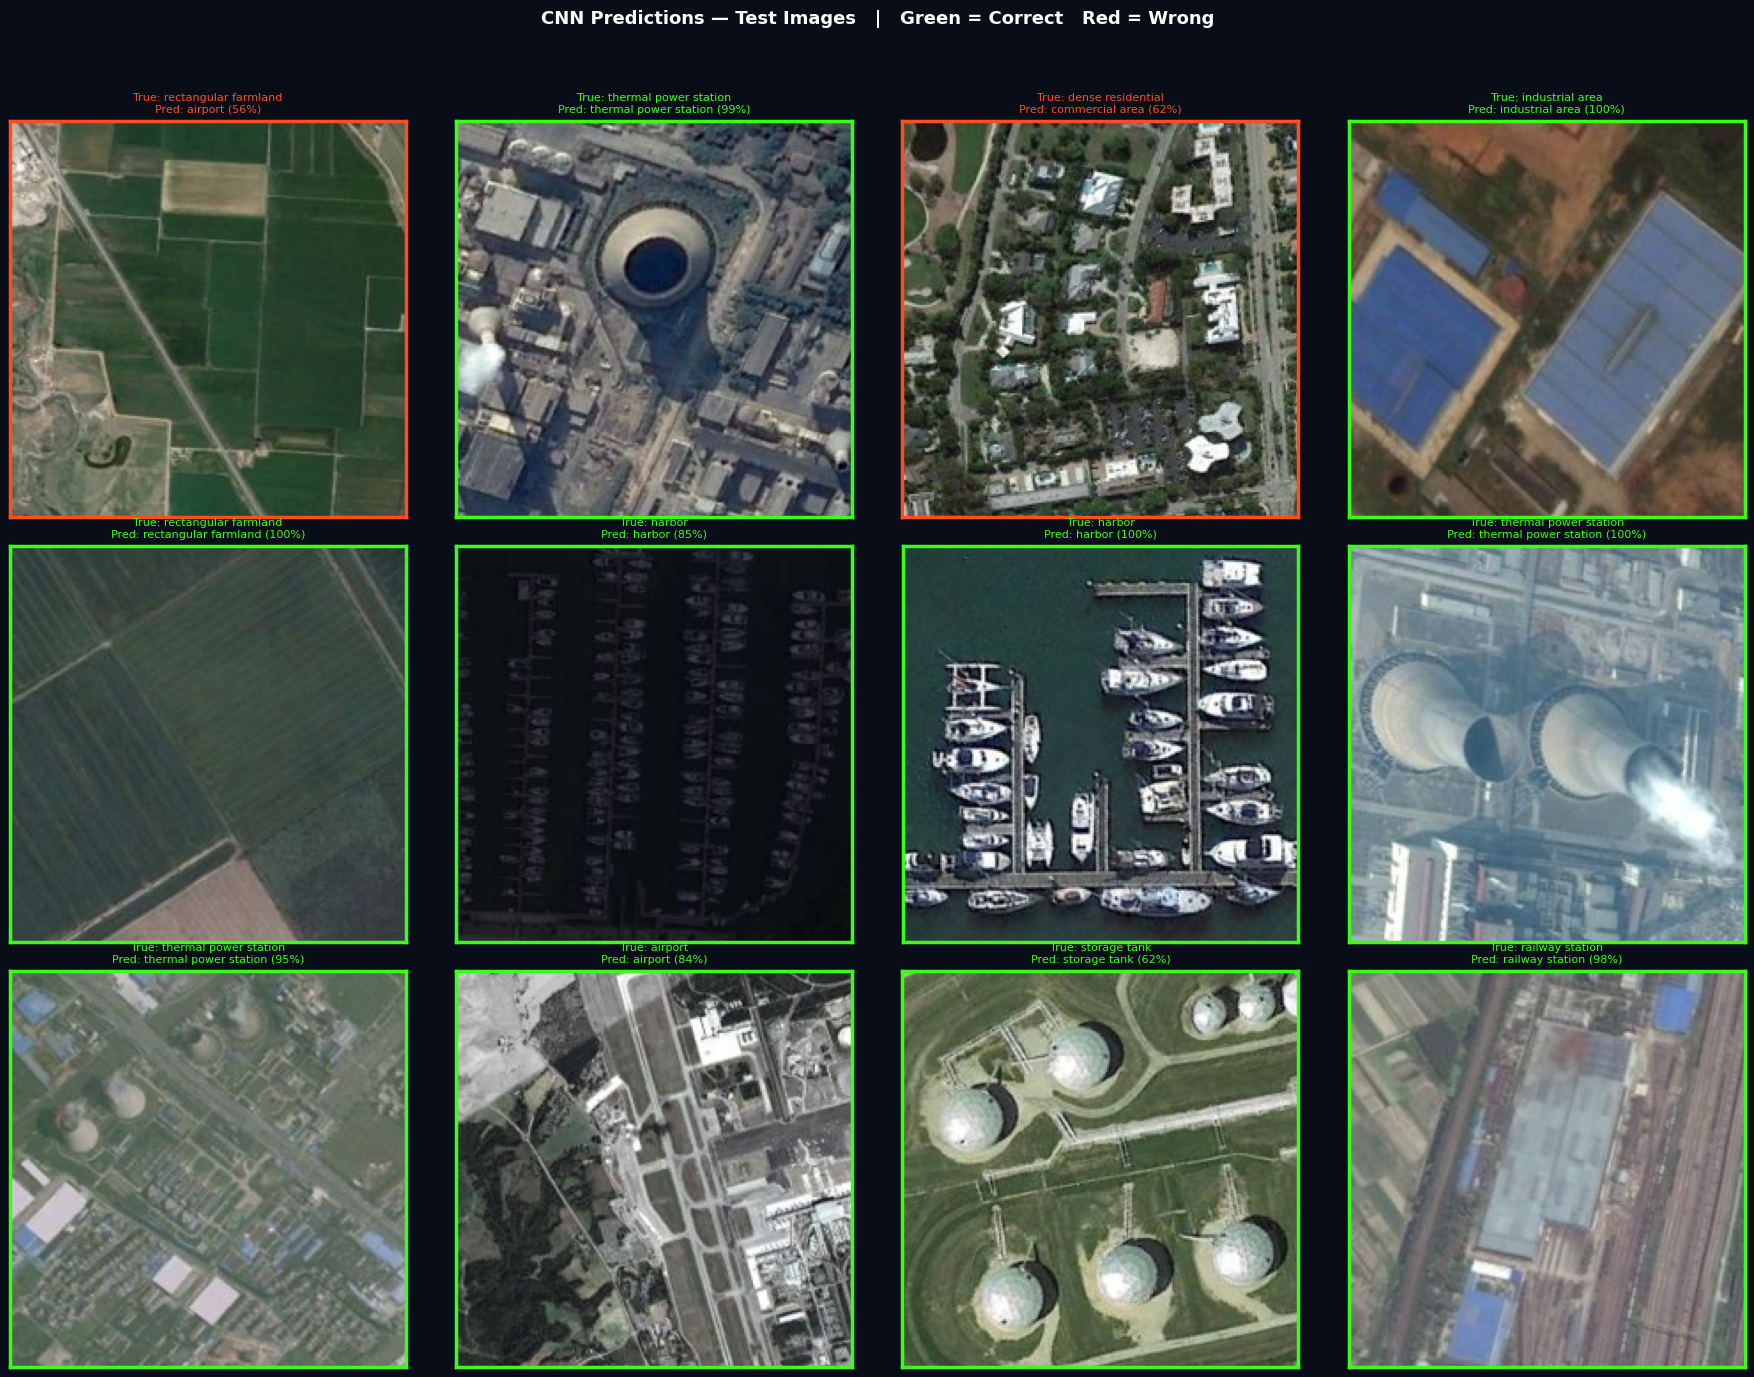

In [ ]:
samples = random.sample(all_test, min(12, len(all_test)))
fig, axes = plt.subplots(3, 4, figsize=(18, 14))
fig.patch.set_facecolor('#080d18')
fig.suptitle('CNN Predictions — Test Images   |   Green = Correct   Red = Wrong',
             color='white', fontsize=13, fontweight='bold')
for ax, p in zip(axes.flat, samples):
    true = p.parent.name
    res  = predict_facility(str(p), top_k=1)
    pred = res['facility_type']; conf = res['confidence']
    ok   = pred == true; color = '#39ff14' if ok else '#ff4d1c'
    ax.imshow(Image.open(p).convert('RGB').resize((224,224)))
    ax.set_title(f"True: {true.replace('_',' ')}\nPred: {pred.replace('_',' ')} ({conf*100:.0f}%)",
                 color=color, fontsize=8)
    for sp in ax.spines.values(): sp.set_edgecolor(color); sp.set_linewidth(2.5)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig(PLOTS_DIR/'07_pred_grid.png', dpi=150, bbox_inches='tight', facecolor='#080d18')
plt.show()

## 💾 Section 13 — Save Model + Metadata

In [ ]:
final = ARTIFACTS_DIR / 'cnn_model.keras'
best_model.save(str(final))
print(f'Model saved  → {final}  ({final.stat().st_size/1024/1024:.1f} MB)')

meta = {
    'model_name': 'CarbonIQ_CNN_Facility_Classifier',
    'base_model': 'MobileNetV2',
    'dataset': 'NWPU-RESISC45',
    'num_classes': NUM_CLASSES,
    'class_names': CLASS_NAMES,
    'class_indices': {k: int(v) for k,v in train_gen.class_indices.items()},
    'class_to_sector': CLASS_TO_SECTOR,
    'class_to_fuel': CLASS_TO_FUEL,
    'input_shape': [224, 224, 3],
    'normalization': 'divide_by_255',
    'confidence_threshold': 0.55,
    'images_per_class_trained': IMAGES_PER_CLASS,
    'test_accuracy': float(results[1]),
    'top3_accuracy': float(results[2]),
    'test_loss': float(results[0]),
}
meta_path = ARTIFACTS_DIR / 'cnn_metadata.json'
with open(meta_path, 'w') as f: json.dump(meta, f, indent=2)
print(f'Metadata saved → {meta_path}')
print('\nAll artifacts:')
for f in sorted(ARTIFACTS_DIR.iterdir()):
    print(f'  {f.name:<30} {f.stat().st_size/1024:.0f} KB')

Model saved  → models_artifacts/cnn_model.keras  (22.2 MB)
Metadata saved → models_artifacts/cnn_metadata.json

All artifacts:
  cnn_metadata.json              2 KB
  cnn_model.keras                22754 KB
  cnn_p1_best.keras              13322 KB
  cnn_p2_best.keras              22760 KB


## 📋 Section 14 — Final Summary

In [ ]:
print('='*62)
print('  CarbonIQ CNN — Final Summary')
print('='*62)
print(f'\n📦 Dataset')
print(f'   Source           : NWPU-RESISC45 (aqibrehmanpirzada/nwpuresisc45)')
print(f'   Classes used     : {NUM_CLASSES} / 45')
print(f'   Images per class : {IMAGES_PER_CLASS} / 700  (fast subset)')
print(f'   Total images     : ~{NUM_CLASSES * IMAGES_PER_CLASS}')
print(f'\n🧠 Model')
print(f'   Architecture     : MobileNetV2 + GAP + Dense({DENSE_UNITS}) + Dropout({DROPOUT})')
print(f'   Phase 1 epochs   : {len(h1.history["accuracy"])} (head only)')
print(f'   Phase 2 epochs   : {len(h2.history["accuracy"])} (top {UNFREEZE_LAYERS} layers unfrozen)')
print(f'   Total params     : {best_model.count_params():,}')
print(f'\n📊 Performance')
print(f'   Test Accuracy    : {results[1]*100:.2f}%')
print(f'   Top-3 Accuracy   : {results[2]*100:.2f}%')
sorted_acc = sorted(zip(CLASS_NAMES, per_class_acc), key=lambda x: -x[1])
print(f'   Best class       : {sorted_acc[0][0]}  ({sorted_acc[0][1]*100:.1f}%)')
print(f'   Worst class      : {sorted_acc[-1][0]}  ({sorted_acc[-1][1]*100:.1f}%)')
print(f'\n🗺️  Class → Sector → Fuel Mapping')
print(f'  {"Class":<28} {"Sector":<22} Fuel')
print('  ' + '-'*64)
for cls in CLASS_NAMES:
    s = CLASS_TO_SECTOR[cls].replace(' carbon dioxide emissions','')
    print(f'  {cls:<28} {s:<22} {CLASS_TO_FUEL[cls]}')

  CarbonIQ CNN — Final Summary

📦 Dataset
   Source           : NWPU-RESISC45 (aqibrehmanpirzada/nwpuresisc45)
   Classes used     : 11 / 45
   Images per class : 150 / 700  (fast subset)
   Total images     : ~1650

🧠 Model
   Architecture     : MobileNetV2 + GAP + Dense(256) + Dropout(0.4)
   Phase 1 epochs   : 10 (head only)
   Phase 2 epochs   : 6 (top 20 layers unfrozen)
   Total params     : 2,593,867

📊 Performance
   Test Accuracy    : 87.35%
   Top-3 Accuracy   : 96.84%
   Best class       : harbor  (100.0%)
   Worst class      : industrial_area  (60.9%)

🗺️  Class → Sector → Fuel Mapping
  Class                        Sector                 Fuel
  ----------------------------------------------------------------
  airport                      Transportation         Petroleum
  commercial_area              Commercial             Natural Gas
  dense_residential            Residential            Natural Gas
  forest                       Residential            Biomass
  freeway  